<a href="https://colab.research.google.com/github/thanhthuy280501/Data-Visualization/blob/main/Data_visualization_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define file paths
gdp_path = '/content/drive/MyDrive/Colab Notebooks/API_NY.GDP.PCAP.PP.CD_DS2_en_excel_v2_589.xls'
pop_path = '/content/drive/MyDrive/Colab Notebooks/API_SP.POP.DPND.OL_DS2_en_excel_v2_2904.xls'
zip_path = '/content/drive/MyDrive/Colab Notebooks/ti-corruption-perception-index.zip'

# Load the datasets
# Note: xlrd or openpyxl might be required for .xls files
df_gdp = pd.read_excel(gdp_path)
df_pop = pd.read_excel(pop_path)

print("Data loaded successfully.")

Data loaded successfully.


In [2]:
import zipfile
import io

with zipfile.ZipFile(zip_path, 'r') as zf:
    with zf.open('ti-corruption-perception-index.csv') as f:
        df_corruption = pd.read_csv(f)
display(df_corruption.head())

,Entity,Code,Year,Corruption Perceptions Index,World region according to OWID
0,Afghanistan,AFG,2012,8,Asia
1,Afghanistan,AFG,2013,8,Asia
2,Afghanistan,AFG,2014,12,Asia
3,Afghanistan,AFG,2015,11,Asia
4,Afghanistan,AFG,2016,15,Asia


In [ ]:
num_countries = df_corruption['Entity'].nunique()
print(f"There are {num_countries} unique countries in the corruption dataset.")

There are 182 unique countries in the corruption dataset.


In [ ]:
num_regions = df_corruption['World region according to OWID'].nunique()
print(f"There are {num_regions} unique regions in the corruption dataset.")

There are 6 unique regions in the corruption dataset.


In [ ]:
unique_countries = df_corruption['Entity'].unique()

print("Countries with missing years:")
for country in unique_countries:
    country_data = df_corruption[df_corruption['Entity'] == country]
    years_present = country_data['Year'].unique()
    years_present = np.sort(years_present) # Fixed line: Use np.sort() on the IntegerArray

    if len(years_present) > 1:
        min_year = years_present.min()
        max_year = years_present.max()
        expected_years = np.arange(min_year, max_year + 1)

        missing_years_for_country = np.setdiff1d(expected_years, years_present)

        if len(missing_years_for_country) > 0:
            print(f"  {country}: Missing years {missing_years_for_country.tolist()}")

Countries with missing years:
  Bahamas: Missing years [2015]
  Barbados: Missing years [2015]
  Brunei: Missing years [2014, 2015]
  Dominica: Missing years [2015]
  Equatorial Guinea: Missing years [2014, 2015, 2016]
  Eswatini: Missing years [2015, 2016]
  Saint Lucia: Missing years [2015]
  Saint Vincent and the Grenadines: Missing years [2015]
  Seychelles: Missing years [2016]


In [ ]:
import numpy as np

unique_countries = df_corruption['Entity'].unique()
countries_with_missing_years = []

for country in unique_countries:
    country_data = df_corruption[df_corruption['Entity'] == country]
    years_present = country_data['Year'].unique()
    years_present = np.sort(years_present)

    if len(years_present) > 1:
        min_year = years_present.min()
        max_year = years_present.max()
        expected_years = np.arange(min_year, max_year + 1)

        missing_years_for_country = np.setdiff1d(expected_years, years_present)

        if len(missing_years_for_country) > 0:
            countries_with_missing_years.append(country)

num_countries_with_nan_years = len(countries_with_missing_years)
print(f"There are {num_countries_with_nan_years} countries with missing 'Corruption Perceptions Index' data for some years within their period.")

There are 9 countries with missing 'Corruption Perceptions Index' data for some years within their period.


In [3]:
grouped_corruption = df_corruption.groupby(['World region according to OWID', 'Year']).agg(
    num_countries=('Entity', 'nunique'),
    avg_corruption_index=('Corruption Perceptions Index', 'mean')
).reset_index()
display(grouped_corruption.head())

,World region according to OWID,Year,num_countries,avg_corruption_index
0,Africa,2012,53,33.320755
1,Africa,2013,54,32.129630
2,Africa,2014,53,32.849057
3,Africa,2015,52,32.307692
4,Africa,2016,51,31.509804


In [4]:
countries_per_region = df_corruption.groupby('World region according to OWID')['Entity'].nunique().reset_index()
countries_per_region.columns = ['World region', 'Number of Countries']
display(countries_per_region.sort_values(by='Number of Countries', ascending=False))

,World region,Number of Countries
0,Africa,54
1,Asia,48
2,Europe,41
3,North America,21
5,South America,12
4,Oceania,6


In [ ]:
pivot_corruption = grouped_corruption.pivot_table(
    index='Year',
    columns='World region according to OWID',
    values='avg_corruption_index'
)
display(pivot_corruption.head())

World region according to OWID,Africa,Asia,Europe,North America,Oceania,South America
Year,,,,,,
2012,33.320755,38.702128,57.829268,49.400000,66.666667,39.250000
2013,32.129630,38.468085,57.902439,48.300000,65.666667,39.166667
2014,32.849057,38.652174,58.560976,49.050000,65.333333,39.583333
2015,32.307692,38.913043,59.585366,41.857143,65.000000,38.500000
2016,31.509804,39.125000,59.121951,46.800000,59.750000,39.583333


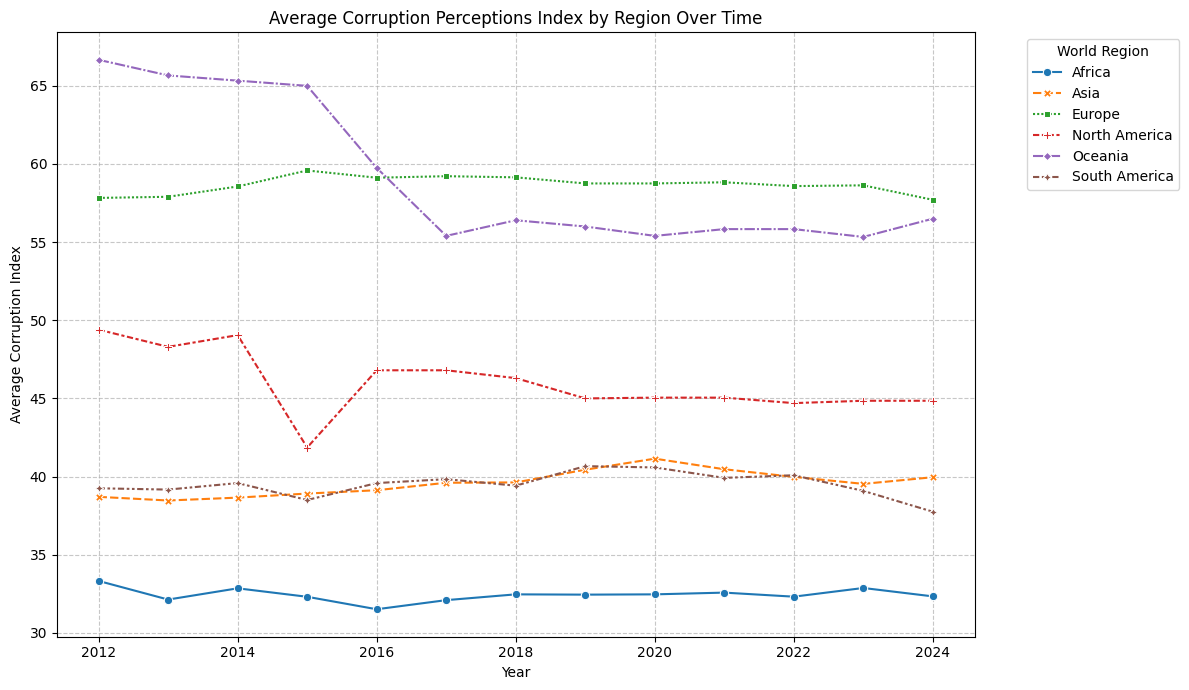

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=pivot_corruption, markers=True)
plt.title('Average Corruption Perceptions Index by Region Over Time')
plt.xlabel('Year')
plt.ylabel('Average Corruption Index')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='World Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()